# Joint SSMT — Single-Trial Quickstart

This notebook walks through the **single-trial** spike-field coupling pipeline:

1. **Simulate** synthetic LFP + spike data with known coupling
2. **Run inference** using the Joint SSMT model
3. **Interpret the core results** — coupling detection heatmaps and spectrogram
4. *(Optional)* Additional diagnostic and comparison plots

The core output answers one question: **which spike units couple to which LFP frequency bands, and how strongly?**

In [ ]:
# If you haven't installed the package yet, uncomment and run:
# !pip install -e ..

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from joint_ssmt import (
    simulate_single_trial,
    SingleTrialSimConfig,
)
from joint_ssmt.io import run_inference, load_results

/opt/homebrew/anaconda3/envs/pyssmt_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Simulate Data

We generate synthetic data with **known** spike-field coupling so we can verify the inference.

The simulation creates:
- An LFP signal containing oscillatory components at several frequencies (11, 19, 27, 43 Hz plus two "signal-only" bands at 7 and 35 Hz that appear in the LFP but do **not** drive spiking)
- Spike trains for 3 units, each coupled to 2 of the 4 couplable bands

> **For real data** you would skip this step and load your own `lfp` (1-D array, shape `(T,)`) and `spikes` (2-D array, shape `(S, T_fine)`).

In [3]:
cfg = SingleTrialSimConfig(
    duration_sec=60.0,  # 60 s (use >=60 s for real analyses)
    S=3,                # 3 spike units
    k_active=2,         # each unit couples to 2 of 4 couplable bands
    b0_mu=-3.0,         # baseline log-odds (controls mean firing rate)
)

sim = simulate_single_trial(cfg, seed=42)

lfp    = sim['LFP']        # (T,)
spikes = sim['spikes']     # (S, T_fine)

print(f"LFP shape:    {lfp.shape}   (T = {lfp.shape[0]} samples at {cfg.fs} Hz)")
print(f"Spikes shape: {spikes.shape} (S = {spikes.shape[0]} units)")
print(f"\nGround-truth coupled frequencies: {sim['freqs_hz_coupled']}")
print(f"Signal-only (uncoupled) frequencies: {sim['freqs_hz_extra']}")
print(f"\nCoupling mask (rows=units, cols=signal bands):")
print(sim['masks'])

Single-trial simulation setup:
  Units: S=3
  Coupled signal bands (Jc=4): [11. 19. 27. 43.]
  Extra uncoupled signal bands (Ju=2): [ 7. 35.]
  Total signal bands (J=6): [11. 19. 27. 43.  7. 35.]
  LFP: T=60000 samples at fs=1000.0 Hz
  Spikes: T_fine=60000 samples at 1000.0 Hz
Generating OU latent processes...
Computing derotated latents for spike predictors...
Generating coupling parameters...
  beta_true shape: (3, 13) (SEPARATED layout)
Generating spikes...
  Spikes per unit: [1334 2283 2205]
  Mean firing rate: 32.34 Hz
  Unit 0 firing rate: 22.23 Hz
  Unit 1 firing rate: 38.05 Hz
  Unit 2 firing rate: 36.75 Hz
Generating LFP with broadband noise...
Simulation complete.
LFP shape:    (60000,)   (T = 60000 samples at 1000.0 Hz)
Spikes shape: (3, 60000) (S = 3 units)

Ground-truth coupled frequencies: [11. 19. 27. 43.]
Signal-only (uncoupled) frequencies: [ 7. 35.]

Coupling mask (rows=units, cols=signal bands):
[[False  True False  True False False]
 [False  True False  True False 

---
## 2. Run Inference

Call `run_inference` with your LFP, spike trains, and config dictionaries.

**Key parameters:**
- `spectral_config` — frequency range, window length, time-bandwidth product
- `inference_config` — MCMC iterations and refresh cycles
- `output_config` — where to save; set `save_spectral=True` to enable spectrogram plots later
- `plot=False` — we will make our own plots below (set `True` to auto-generate defaults)

> **Timing:** ~1–2 min for 30 s of data with these settings. For publication quality, increase `warmup_iterations` to 1000 and `n_refresh_cycles` to 5.

In [4]:
saved = run_inference(
    lfp=lfp,
    spikes=spikes,
    spectral_config={
        'freq_min': 1.0,
        'freq_max': 61.0,
        'freq_step': 1.0,
        'window_sec': 2.0,
        'time_bandwidth': 2.0,
    },
    inference_config={
        'warmup_iterations': 300,
        'n_refresh_cycles': 2,
        'iterations_per_refresh': 100,
    },
    output_config={
        'output_dir': './results_single',
        'save_spectral': True,
    },
    fs=cfg.fs,
    plot=False,
)

print("Saved files:")
for k, v in saved.items():
    print(f"  {k}: {v}")

[EM-CT-JAX] iter    0  Q = -3.5835e+04
[EM-CT-JAX] Converged at iter 49  Q = -2.7156e+04


Warmup (PG-Gibbs): 100%|██████████| 300/300 [03:06<00:00,  1.60it/s]
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_single_trial.py:778: RuntimeWarning: divide by zero encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_single_trial.py:778: RuntimeWarning: overflow encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_single_trial.py:778: RuntimeWarning: invalid value encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_single_trial.py:1000: RuntimeWarning: divide by zero encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_single_trial.py:1000: RuntimeWarning: overflow e

Saved files:
  coupling: ./results_single/coupling.npz
  spectral: ./results_single/spectral.npz
  metadata: ./results_single/metadata.json


---
## 3. Core Results

The results are stored as `.npz` and `.json` files. Use `load_results()` to read them into a single dictionary.

In [5]:
results = load_results('./results_single')

# The main results live under 'coupling'
coupling = results['coupling']
freqs    = coupling['freqs']       # (J,) frequency grid
beta_mag = coupling['beta_mag']    # (S, J) posterior mean |beta|

S, J = beta_mag.shape
print(f"Frequency grid: {J} bands from {freqs[0]:.0f} to {freqs[-1]:.0f} Hz")
print(f"Units: {S}")

Frequency grid: 60 bands from 1 to 60 Hz
Units: 3


### 3a. Coupling Detection Heatmap

This is **the key figure**. The Wald test checks whether each complex coupling coefficient $\beta$ is significantly different from zero.

- **Left panel:** posterior mean coupling magnitude $|\mathbb{E}[\beta]|$ — larger values indicate stronger coupling
- **Right panel:** $-\log_{10}(p)$ from the Wald $\chi^2(2)$ test — values above the cyan line ($\alpha = 0.05$) are statistically significant

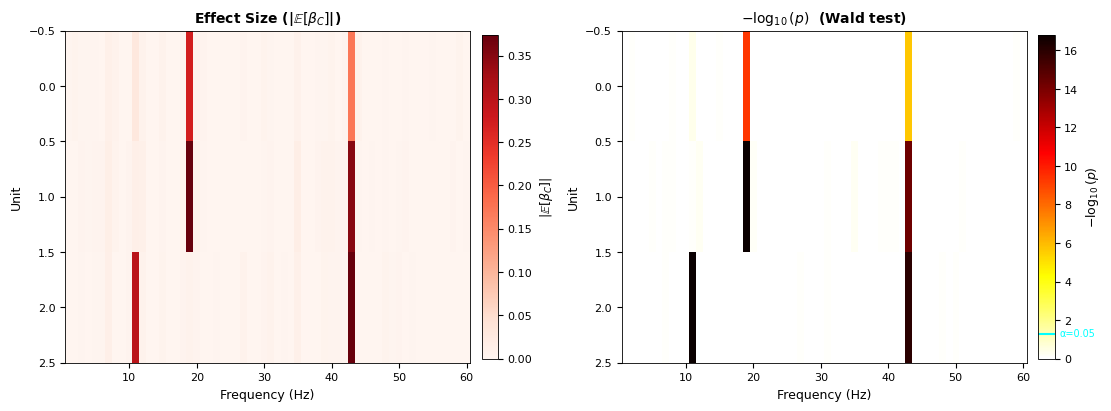

In [6]:
from joint_ssmt.plotting.summary import plot_coupling_summary

fig = plot_coupling_summary(results, effect_type='wald', alpha=0.05, figsize=(11, 4))
plt.show()

### 3b. Significant Coupling Pairs

Read off which (unit, frequency) pairs pass the Wald test.

In [7]:
wald_pval = coupling['wald_pval']   # (S, J)
wald_W    = coupling['wald_W']      # (S, J)
alpha = 0.05

print(f"Significant coupling pairs (alpha = {alpha}):\n")
print(f"  {'Unit':>4}  {'Freq (Hz)':>10}  {'|beta|':>8}  {'Wald W':>8}  {'p-value':>10}")
print("  " + "-" * 50)

for s in range(S):
    for j in range(J):
        if wald_pval[s, j] < alpha:
            print(f"  {s:>4}  {freqs[j]:>10.0f}  {beta_mag[s, j]:>8.4f}  "
                  f"{wald_W[s, j]:>8.2f}  {wald_pval[s, j]:>10.2e}")

Significant coupling pairs (alpha = 0.05):

  Unit   Freq (Hz)    |beta|    Wald W     p-value
  --------------------------------------------------
     0          19    0.2716     42.73    5.25e-10
     0          43    0.1722     26.25    1.99e-06
     1          19    0.4687    158.53    0.00e+00
     1          43    0.3489     65.79    5.22e-15
     2          11    0.3004    132.66    0.00e+00
     2          43    0.5147     74.67    1.11e-16


### 3c. Spectrogram

The inferred spectrogram shows how spectral power evolves over time.
This works on **real data** too (no ground truth needed).
The joint model refines the raw multitaper estimate by leveraging spike information.

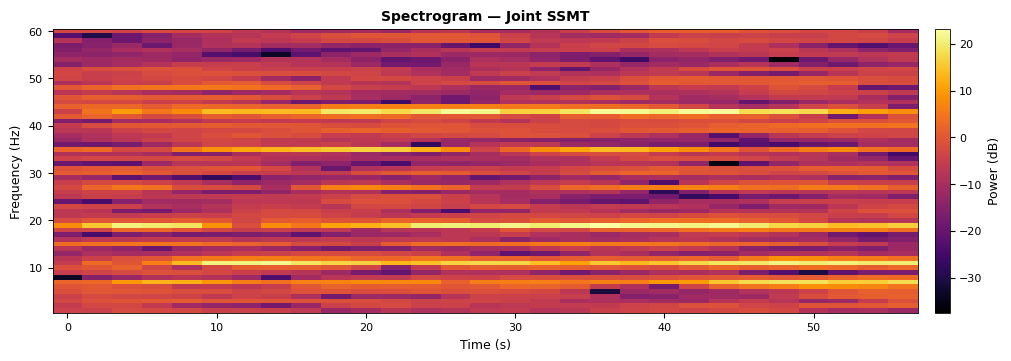

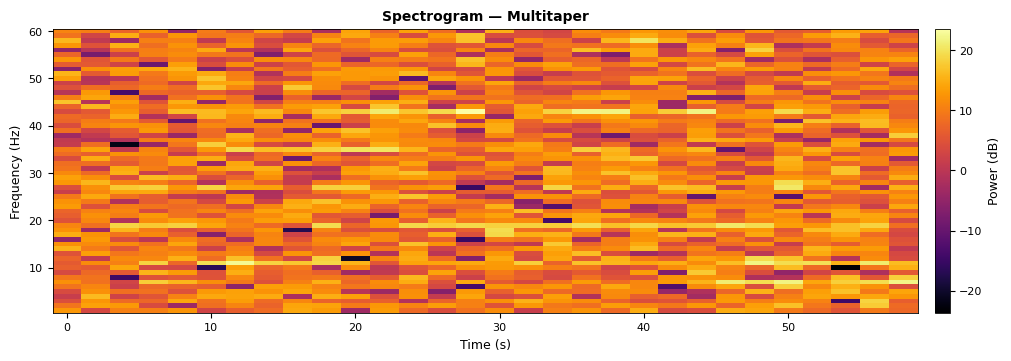

In [8]:
from joint_ssmt.plotting.summary import plot_spectrogram

# Joint model spectrogram (refined by spike information)
fig = plot_spectrogram(results, method='joint', figsize=(10, 3.5))
plt.show()

# Raw multitaper spectrogram (LFP only, for comparison)
fig = plot_spectrogram(results, method='multitaper', figsize=(10, 3.5))
plt.show()

### 3d. Run Metadata

The `metadata.json` file records the configs and timing for reproducibility.

In [9]:
meta = results['metadata']
print(f"Elapsed time:      {meta['timing']['elapsed_seconds']:.1f} s")
print(f"MCMC samples:      {meta['mcmc']['n_samples']}")
print(f"Significant bands: {meta['detection']['n_significant_bands']}")
print(f"Frequency grid:    {meta['ctssmt']['n_freqs']} bands")

Elapsed time:      330.7 s
MCMC samples:      250
Significant bands: 3
Frequency grid:    60 bands


---
## 4. Additional Plots (Optional)

The plots below are useful for deeper analysis.
They are **not required** for basic interpretation.

### 4a. Ground-Truth Comparison (simulation only)

When you have ground-truth coupling (from simulation), overlay true values with inferred.

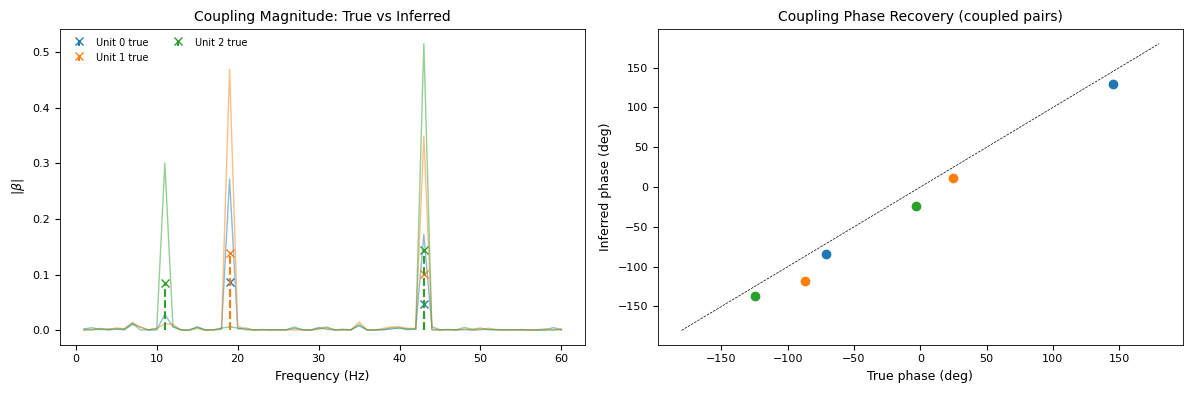

In [10]:
gt_mag    = sim['beta_mag']       # (S, J_true)
gt_phase  = sim['beta_phase']     # (S, J_true)
gt_freqs  = sim['freqs_hz']       # all signal band frequencies
masks     = sim['masks']          # (S, J_true) coupling mask
beta_phase = coupling['beta_phase']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- Magnitude --
for s in range(S):
    coupled = masks[s]
    axes[0].stem(
        gt_freqs[coupled], gt_mag[s, coupled],
        linefmt=f'C{s}--', markerfmt=f'C{s}x', basefmt=' ',
        label=f'Unit {s} true',
    )
    axes[0].plot(freqs, beta_mag[s], '-', color=f'C{s}', alpha=0.5, lw=1)

axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel(r'$|\beta|$')
axes[0].set_title('Coupling Magnitude: True vs Inferred')
axes[0].legend(fontsize=7, ncol=2)

# -- Phase --
idx_map = [np.argmin(np.abs(freqs - f)) for f in gt_freqs]
for s in range(S):
    coupled = masks[s]
    for jt in np.where(coupled)[0]:
        axes[1].plot(
            np.degrees(gt_phase[s, jt]),
            np.degrees(beta_phase[s, idx_map[jt]]),
            'o', color=f'C{s}', markersize=6,
        )
axes[1].plot([-180, 180], [-180, 180], 'k--', lw=0.5)
axes[1].set_xlabel('True phase (deg)')
axes[1].set_ylabel('Inferred phase (deg)')
axes[1].set_title('Coupling Phase Recovery (coupled pairs)')

plt.tight_layout()
plt.show()

### 4b. Beta Posterior Scatter

Visualize the full posterior distribution of $\beta = \beta_R + i\beta_I$ for each frequency.
Coupled bands show a concentrated posterior away from the origin.

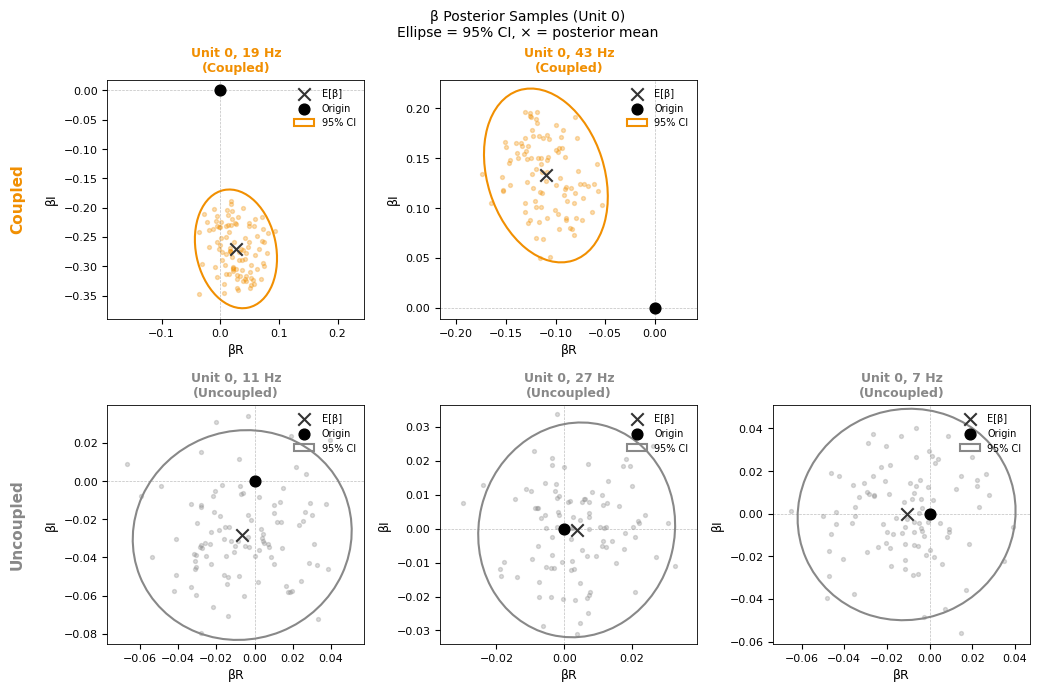

In [11]:
from joint_ssmt.plotting.beta_posterior import plot_beta_posterior_scatter

fig = plot_beta_posterior_scatter(
    coupling['beta_trace'],
    freqs,
    None,  # pass a file path to save, or None = display only
    unit_idx=0,
    burn_in_frac=0.6,
    freqs_true=gt_freqs,
    masks=masks,
)
plt.show()

### 4c. Detailed Heatmaps

Publication-quality heatmaps with ground-truth overlay markers.

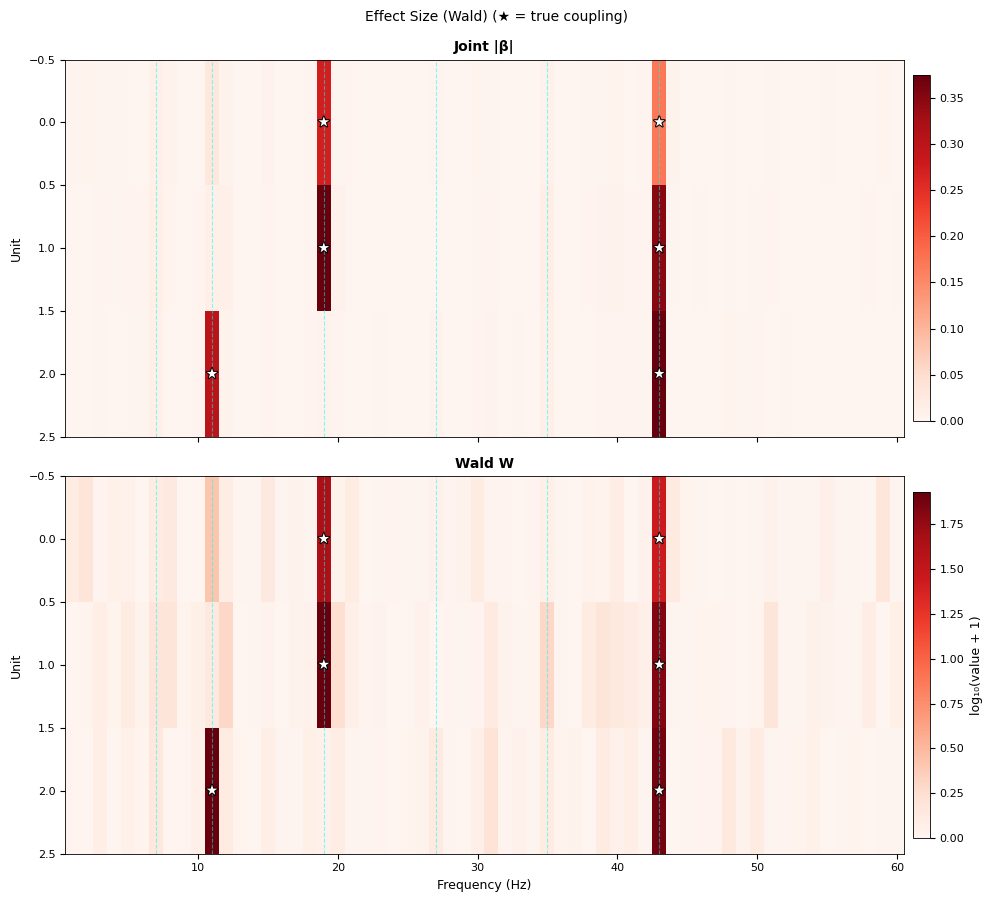

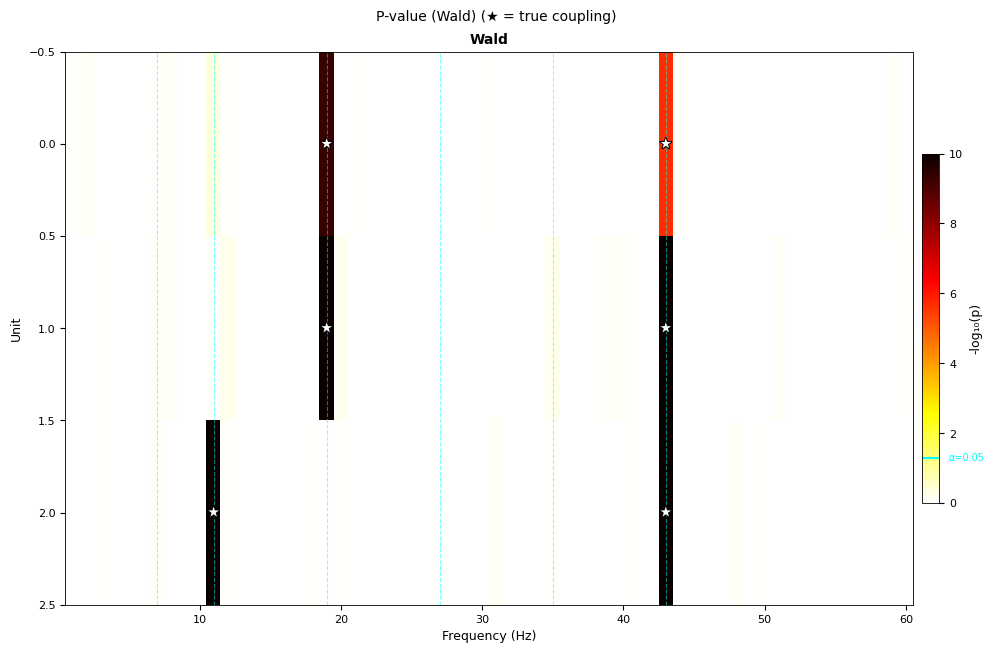

In [12]:
from joint_ssmt.plotting.heatmaps import (
    set_publication_style,
    plot_effect_comparison,
    plot_pval_comparison,
)

set_publication_style()

# Effect size
plot_effect_comparison(
    {'Joint |\u03b2|': beta_mag, 'Wald W': coupling['wald_W']},
    freqs, None,
    true_freqs=gt_freqs, masks=masks,
    log_scale_keys=('Wald W',),
    suptitle='Effect Size (Wald)',
)
plt.show()

# P-value
plot_pval_comparison(
    {'Wald': coupling['wald_pval']},
    freqs, None,
    true_freqs=gt_freqs, masks=masks,
    alpha=0.05, suptitle='P-value (Wald)',
)
plt.show()

### 4d. Spectral Dynamics Comparison (simulation only)

Compare multitaper, EM-only, and joint spectral estimates against
ground-truth latent dynamics. Requires `save_spectral=True`.

In [13]:
from joint_ssmt.io import results_to_legacy_dict
from joint_ssmt.plotting.spectral_dynamics import generate_spectral_dynamics_figures
import os

legacy = results_to_legacy_dict('./results_single')
dynamics_dir = './results_single/dynamics'
os.makedirs(dynamics_dir, exist_ok=True)

generate_spectral_dynamics_figures(
    sim, legacy, dynamics_dir,
    window_sec=10.0,
    n_snapshots=2,
    snapshot_sec=5.0,
)
print(f"Saved to {dynamics_dir}/")

  Duration: 60.0s, J: 60, M: 3
  Ground truth available: True
  Computing multitaper...
  Scales: MT=0.044, LFP=1.410, Joint=1.082
  Generating spectrogram comparison...
  Generating time series snapshots...
  Computing correlations (window = 10.0s)...
  Generating correlation over time...


/opt/homebrew/anaconda3/envs/pyssmt_py312/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


  Generating correlation boxplot...
Saved to ./results_single/dynamics/
